In [1]:
import os, glob
import numpy as np
import pandas as pd
import seaborn as sn
import soundfile
import librosa
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier

print('All libraries imported.')

All libraries imported.


In [2]:
def feature_chromagram(waveform, sample_rate):
    stft_spectrogram = np.abs(librosa.stft(waveform))
    chromagram = np.mean(librosa.feature.chroma_stft(S=stft_spectrogram, sr=sample_rate).T, axis=0)
    return chromagram

def feature_melspectrogram(waveform, sample_rate):
    melspectrogram = np.mean(librosa.feature.melspectrogram(y=waveform, sr=sample_rate, n_mels=128, fmax=8000).T, axis=0)
    return melspectrogram

def feature_mfcc(waveform, sample_rate):
    mfc_coefficients = np.mean(librosa.feature.mfcc(y=waveform, sr=sample_rate, n_mfcc=40).T, axis=0)
    return mfc_coefficients

def preprocess_waveform(waveform):
    if len(waveform.shape) > 1:
        waveform = librosa.to_mono(waveform)
    return waveform

def get_features(file):
    with soundfile.SoundFile(file) as audio:
        waveform = audio.read(dtype='float32')
        sample_rate = audio.samplerate
        waveform = preprocess_waveform(waveform)
        chromagram      = feature_chromagram(waveform, sample_rate)
        melspectrogram  = feature_melspectrogram(waveform, sample_rate)
        mfc_coefficients = feature_mfcc(waveform, sample_rate)
        return np.hstack((chromagram, melspectrogram, mfc_coefficients))

emotions_dict = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

emotion_list = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

print('Feature extraction functions defined.')

Feature extraction functions defined.


In [ ]:
features  = pd.read_csv('featuresRavdess.csv', index_col=0).values
emotions  = pd.read_csv('emotionsRavdess.csv', index_col=0).values.ravel()

print(f'RAVDESS samples: {features.shape[0]}, features per sample: {features.shape[1]}')

RAVDESS samples: 1447, features per sample: 180


In [4]:
# Fit StandardScaler on ALL RAVDESS features — keep this scaler object
standard_scaler  = StandardScaler()
features_scaled  = standard_scaler.fit_transform(features)

# 80/20 train/test split (same random_state as tutorial so results match)
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, emotions, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}')

Training samples: 1157, Test samples: 290


In [ ]:
mlp_model = MLPClassifier(
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    hidden_layer_sizes=(300,),
    learning_rate='adaptive',
    max_iter=1000,
    random_state=42
)

mlp_model.fit(X_train, y_train)

ravdess_preds = mlp_model.predict(X_test)
ravdess_acc   = accuracy_score(y_test, ravdess_preds)

print(f'MLP training accuracy: {100*mlp_model.score(X_train, y_train):.2f}%')
print(f'MLP RAVDESS test accuracy: {100*ravdess_acc:.2f}%')

MLP training accuracy: 99.31%
MLP RAVDESS test accuracy: 71.72%


In [ ]:
PERSONAL_RECORDINGS_PATH = 'data/Actor_25'

def load_personal_data(folder_path):
    X, y = [], []
    files_found = sorted(glob.glob(os.path.join(folder_path, '*.wav')))
    if not files_found:
        raise FileNotFoundError(f'No .wav files found in: {folder_path}')
    for file in files_found:
        file_name = os.path.basename(file)
        emotion   = emotions_dict[file_name.split('-')[2]]
        X.append(get_features(file))
        y.append(emotion)
        print(f'  Loaded: {file_name}  →  {emotion}')
    return np.array(X), np.array(y)

personal_features, personal_emotions = load_personal_data(PERSONAL_RECORDINGS_PATH)
print(f'\nPersonal recordings loaded: {personal_features.shape[0]} samples')

  Loaded: 03-01-01-01-02-01-25.wav  →  neutral
  Loaded: 03-01-02-01-02-01-25.wav  →  calm
  Loaded: 03-01-03-02-02-01-25.wav  →  happy
  Loaded: 03-01-04-01-02-01-25.wav  →  sad
  Loaded: 03-01-05-02-02-01-25.wav  →  angry
  Loaded: 03-01-06-01-02-01-25.wav  →  fearful
  Loaded: 03-01-07-02-02-01-25.wav  →  disgust
  Loaded: 03-01-08-02-02-01-25.wav  →  surprised

Personal recordings loaded: 8 samples


In [7]:
# Scale personal recordings using the RAVDESS-fitted scaler (transform only, no refit)
personal_features_scaled = standard_scaler.transform(personal_features)

personal_preds = mlp_model.predict(personal_features_scaled)
personal_acc   = accuracy_score(personal_emotions, personal_preds)

print('=== MLP on Personal Recordings ===')
print(f'Accuracy:  {100*personal_acc:.2f}%')
print(f'Precision: {100*precision_score(personal_emotions, personal_preds, average="macro", zero_division=0):.2f}%')
print(f'Recall:    {100*recall_score(personal_emotions, personal_preds, average="macro", zero_division=0):.2f}%')
print(f'F-Score:   {100*f1_score(personal_emotions, personal_preds, average="macro", zero_division=0):.2f}%')

print('\nPredicted vs actual:')
for actual, predicted in zip(personal_emotions, personal_preds):
    match = '✓' if actual == predicted else '✗'
    print(f'  {match}  actual: {actual:<12}  predicted: {predicted}')

=== MLP on Personal Recordings ===
Accuracy:  12.50%
Precision: 1.56%
Recall:    12.50%
F-Score:   2.78%

Predicted vs actual:
  ✗  actual: neutral       predicted: calm
  ✓  actual: calm          predicted: calm
  ✗  actual: happy         predicted: calm
  ✗  actual: sad           predicted: calm
  ✗  actual: angry         predicted: calm
  ✗  actual: fearful       predicted: calm
  ✗  actual: disgust       predicted: calm
  ✗  actual: surprised     predicted: calm


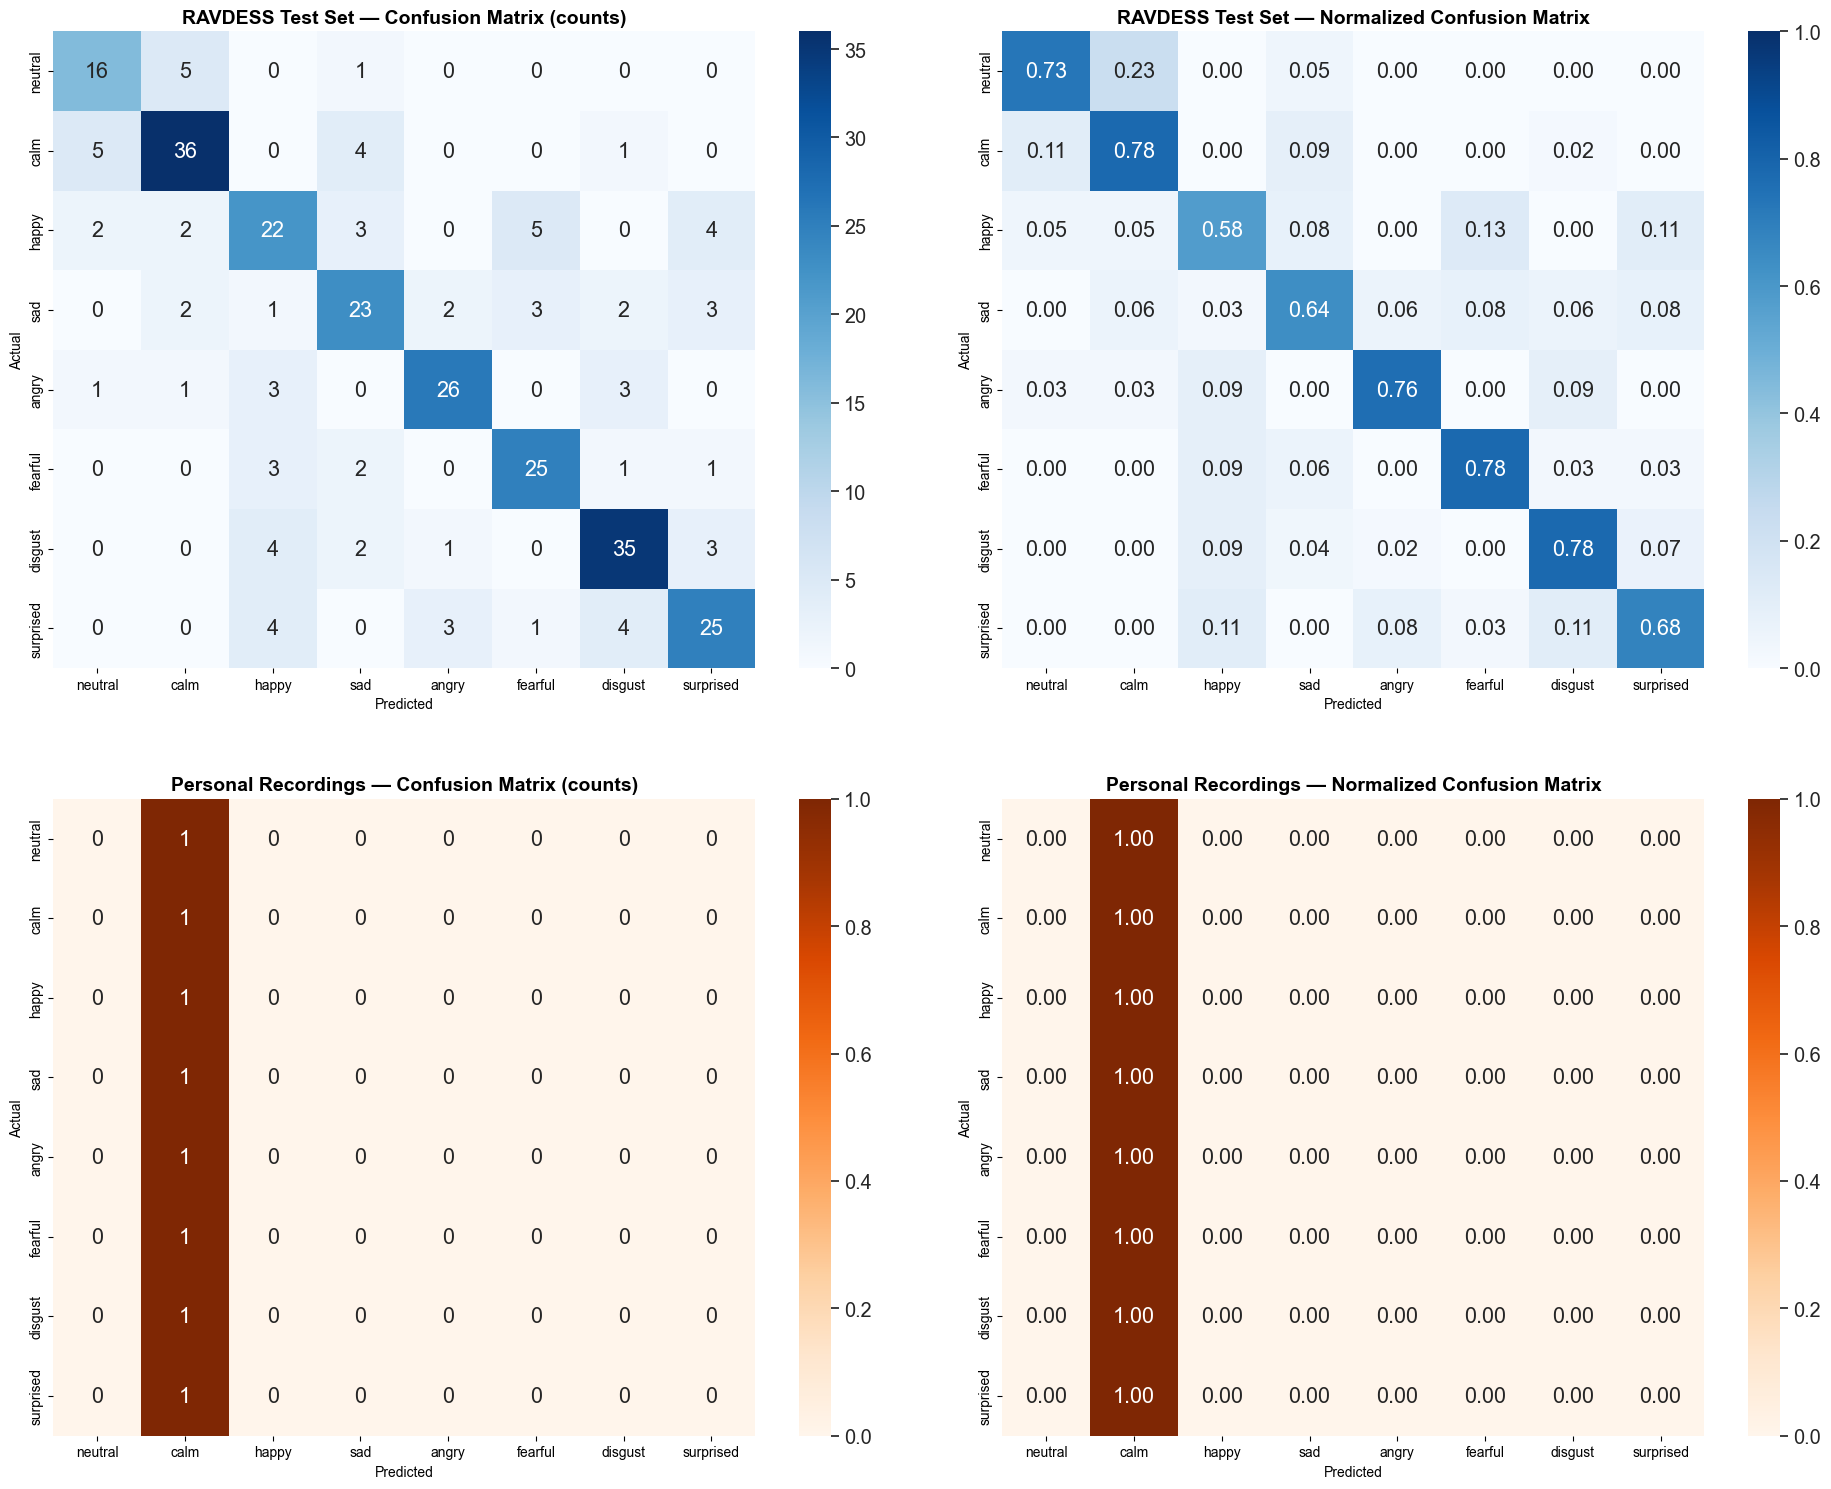

Saved: confusion_matrices.png


In [8]:
# Build both confusion matrices
ravdess_cm  = confusion_matrix(y_test,           ravdess_preds,  labels=emotion_list)
personal_cm = confusion_matrix(personal_emotions, personal_preds, labels=emotion_list)

ravdess_cm_norm  = confusion_matrix(y_test,           ravdess_preds,  labels=emotion_list, normalize='true')
personal_cm_norm = confusion_matrix(personal_emotions, personal_preds, labels=emotion_list, normalize='true')

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
sn.set(font_scale=1.3)

# Raw counts — RAVDESS
sn.heatmap(pd.DataFrame(ravdess_cm, index=emotion_list, columns=emotion_list),
           annot=True, fmt='d', cmap='Blues', ax=axes[0][0])
axes[0][0].set_title('RAVDESS Test Set — Confusion Matrix (counts)', fontsize=14, fontweight='bold')
axes[0][0].set_xlabel('Predicted'); axes[0][0].set_ylabel('Actual')

# Normalised — RAVDESS
sn.heatmap(pd.DataFrame(ravdess_cm_norm, index=emotion_list, columns=emotion_list).round(2),
           annot=True, fmt='.2f', cmap='Blues', ax=axes[0][1], vmin=0, vmax=1)
axes[0][1].set_title('RAVDESS Test Set — Normalized Confusion Matrix', fontsize=14, fontweight='bold')
axes[0][1].set_xlabel('Predicted'); axes[0][1].set_ylabel('Actual')

# Raw counts — Personal
sn.heatmap(pd.DataFrame(personal_cm, index=emotion_list, columns=emotion_list),
           annot=True, fmt='d', cmap='Oranges', ax=axes[1][0])
axes[1][0].set_title('Personal Recordings — Confusion Matrix (counts)', fontsize=14, fontweight='bold')
axes[1][0].set_xlabel('Predicted'); axes[1][0].set_ylabel('Actual')

# Normalised — Personal
sn.heatmap(pd.DataFrame(personal_cm_norm, index=emotion_list, columns=emotion_list).round(2),
           annot=True, fmt='.2f', cmap='Oranges', ax=axes[1][1], vmin=0, vmax=1)
axes[1][1].set_title('Personal Recordings — Normalized Confusion Matrix', fontsize=14, fontweight='bold')
axes[1][1].set_xlabel('Predicted'); axes[1][1].set_ylabel('Actual')

plt.tight_layout(pad=3.0)
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

In [9]:
from sklearn.metrics import classification_report

print('=== RAVDESS Test Set — Per-Class Report ===')
print(classification_report(y_test, ravdess_preds, labels=emotion_list, zero_division=0))

print('=== Personal Recordings — Per-Class Report ===')
print(classification_report(personal_emotions, personal_preds, labels=emotion_list, zero_division=0))

=== RAVDESS Test Set — Per-Class Report ===
              precision    recall  f1-score   support

     neutral       0.67      0.73      0.70        22
        calm       0.78      0.78      0.78        46
       happy       0.59      0.58      0.59        38
         sad       0.66      0.64      0.65        36
       angry       0.81      0.76      0.79        34
     fearful       0.74      0.78      0.76        32
     disgust       0.76      0.78      0.77        45
   surprised       0.69      0.68      0.68        37

    accuracy                           0.72       290
   macro avg       0.71      0.72      0.71       290
weighted avg       0.72      0.72      0.72       290

=== Personal Recordings — Per-Class Report ===
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00         1
        calm       0.12      1.00      0.22         1
       happy       0.00      0.00      0.00         1
         sad       0.00      0.00      0.

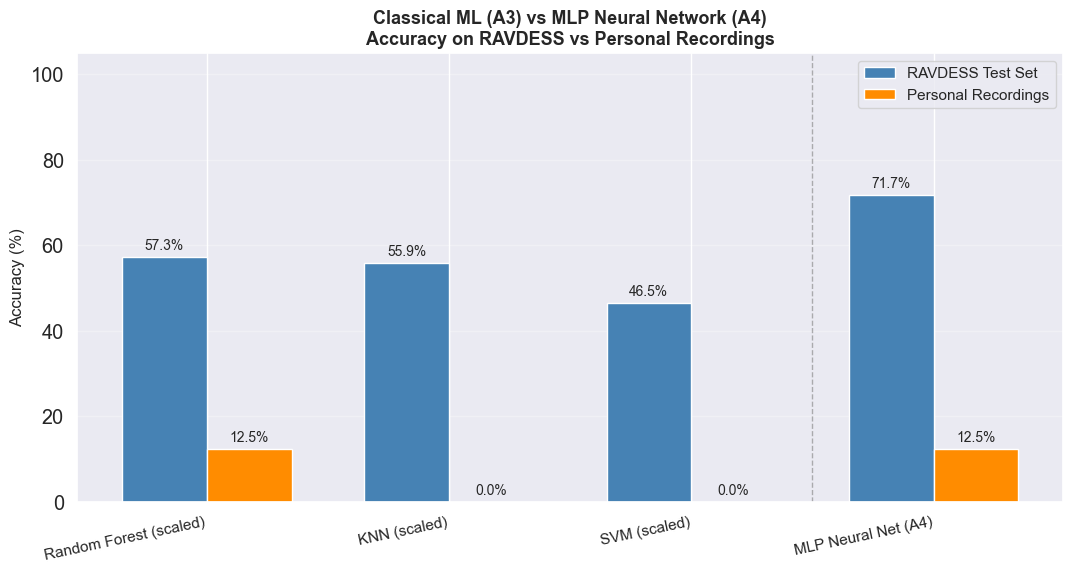

Saved: model_comparison.png


In [ ]:
A3_RAVDESS = {
    'Random Forest (scaled)': 57.29,
    'KNN (scaled)':           55.90,
    'SVM (scaled)':           46.53,
}
A3_PERSONAL = {
    'Random Forest (scaled)': 12.50,
    'KNN (scaled)':            0.00,
    'SVM (scaled)':            0.00,
}

model_names = list(A3_RAVDESS.keys()) + ['MLP Neural Net (A4)']
ravdess_accs  = list(A3_RAVDESS.values())  + [100 * ravdess_acc]
personal_accs = list(A3_PERSONAL.values()) + [100 * personal_acc]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, ravdess_accs,  width, label='RAVDESS Test Set',      color='steelblue')
bars2 = ax.bar(x + width/2, personal_accs, width, label='Personal Recordings',    color='darkorange')

ax.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=12, ha='right', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Classical ML (A3) vs MLP Neural Network (A4)\nAccuracy on RAVDESS vs Personal Recordings', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

MLP training time:           8.90s
Random Forest training time: 14.47s


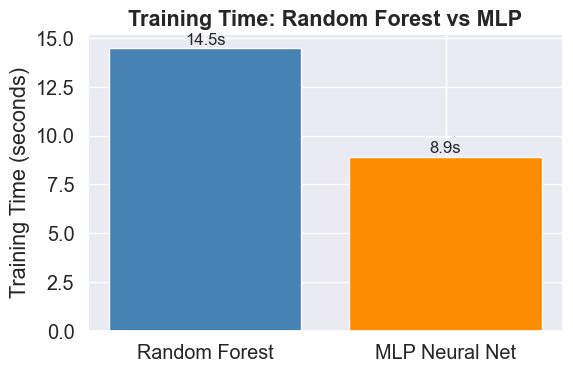

Saved: training_time.png


In [11]:
import time

# Time the MLP
mlp_temp = MLPClassifier(
    activation='relu', solver='adam', alpha=0.001, batch_size=256,
    hidden_layer_sizes=(300,), learning_rate='adaptive', max_iter=1000, random_state=42
)
start = time.time()
mlp_temp.fit(X_train, y_train)
mlp_time = time.time() - start

# Time Random Forest
rf_temp = RandomForestClassifier(n_estimators=500, criterion='entropy',
                                  max_features='sqrt', random_state=42)
start = time.time()
rf_temp.fit(X_train, y_train)
rf_time = time.time() - start

print(f'MLP training time:           {mlp_time:.2f}s')
print(f'Random Forest training time: {rf_time:.2f}s')

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Random Forest', 'MLP Neural Net'], [rf_time, mlp_time], color=['steelblue', 'darkorange'])
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time: Random Forest vs MLP', fontweight='bold')
for i, v in enumerate([rf_time, mlp_time]):
    ax.text(i, v + 0.2, f'{v:.1f}s', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_time.png')

In [12]:
summary = pd.DataFrame({
    'Model': [
        'Random Forest (A3, scaled)',
        'KNN (A3, scaled)',
        'SVM (A3, scaled)',
        'MLP Neural Net (A4)'
    ],
    'RAVDESS Test Acc (%)': [
        57.29, 55.90, 46.53,
        round(100*ravdess_acc, 2)
    ],
    'Personal Acc (%)': [
        12.50, 0.00, 0.00,
        round(100*personal_acc, 2)
    ],
    'RAVDESS Precision (%)': [
        '-', '-', '-',
        round(100*precision_score(y_test, ravdess_preds, average='macro', zero_division=0), 2)
    ],
    'RAVDESS Recall (%)': [
        '-', '-', '-',
        round(100*recall_score(y_test, ravdess_preds, average='macro', zero_division=0), 2)
    ],
    'RAVDESS F-Score (%)': [
        '-', '-', '-',
        round(100*f1_score(y_test, ravdess_preds, average='macro', zero_division=0), 2)
    ]
})

print(summary.to_string(index=False))

                     Model  RAVDESS Test Acc (%)  Personal Acc (%) RAVDESS Precision (%) RAVDESS Recall (%) RAVDESS F-Score (%)
Random Forest (A3, scaled)                 57.29              12.5                     -                  -                   -
          KNN (A3, scaled)                 55.90               0.0                     -                  -                   -
          SVM (A3, scaled)                 46.53               0.0                     -                  -                   -
       MLP Neural Net (A4)                 71.72              12.5                  71.3              71.59               71.41
